# 📰 News Topic Classifier — BERT Fine-tuning on AG News

**Internship Task 1 | DevelopersHub Corporation**

This notebook walks through all 5 phases end-to-end:

| Phase | Description |
|-------|-------------|
| 1 | Install dependencies & load dataset |
| 2 | Tokenization & preprocessing |
| 3 | Fine-tune BERT |
| 4 | Evaluate (Accuracy, F1, Confusion Matrix) |
| 5 | Deploy interactive Gradio app |

> ⚡ **Make sure GPU is enabled**: `Runtime → Change runtime type → T4 GPU`

---
## ⚙️ Phase 1 — Install Dependencies & Load Dataset

In [1]:
# Install all required libraries
# accelerate is required by Hugging Face Trainer for fp16 / multi-GPU support
!pip install -q transformers datasets accelerate gradio scikit-learn

In [2]:
# ── Imports (used across all phases) ─────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# ── Global constants ──────────────────────────────────────────────────────────
MODEL_NAME  = "bert-base-uncased"   # pre-trained BERT checkpoint
MAX_LENGTH  = 128                   # token limit per headline (AG News is short)
OUTPUT_DIR  = "./model_output"      # where the fine-tuned model will be saved
NUM_LABELS  = 4

LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
LABEL2ID    = {n: i for i, n in enumerate(LABEL_NAMES)}
ID2LABEL    = {i: n for i, n in enumerate(LABEL_NAMES)}

# Verify GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [5]:
# ── Download AG News from Hugging Face Hub ────────────────────────────────────
# AG News has 4 classes: World=0, Sports=1, Business=2, Sci/Tech=3
# Train: 120,000 samples  |  Test: 7,600 samples
print("Downloading AG News dataset...")
raw_dataset = load_dataset("fancyzhx/ag_news")

train_raw = raw_dataset["train"]
test_raw  = raw_dataset["test"]

print(f"  Train samples : {len(train_raw):,}")
print(f"  Test  samples : {len(test_raw):,}")
# then Runtime → Restart session → re-run all cellsSonnet 4.6 Low

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

  Train samples : 120,000
  Test  samples : 7,600


In [6]:
# ── Explore the dataset ───────────────────────────────────────────────────────
print("── Sample headlines ──────────────────────────────────────────")
for i in range(4):
    sample = train_raw[i]
    label  = LABEL_NAMES[sample["label"]]
    print(f"  [{label:8s}] {sample['text'][:90]}")

# Class distribution
print("\n── Class distribution (train) ────────────────────────────────")
df = pd.DataFrame(train_raw)
counts = df["label"].value_counts().sort_index()
for idx, cnt in counts.items():
    print(f"  {LABEL_NAMES[idx]:10s}: {cnt:,} samples")

# Headline length stats — helps confirm MAX_LENGTH=128 is safe
df["text_len"] = df["text"].str.len()
print(f"\n── Headline length (characters) ──────────────────────────────")
print(f"  Mean   : {df['text_len'].mean():.0f}")
print(f"  Median : {df['text_len'].median():.0f}")
print(f"  95th % : {df['text_len'].quantile(0.95):.0f}")
print(f"  Max    : {df['text_len'].max()}")

── Sample headlines ──────────────────────────────────────────
  [Business] Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's d
  [Business] Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carl
  [Business] Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worrie
  [Business] Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have ha

── Class distribution (train) ────────────────────────────────
  World     : 30,000 samples
  Sports    : 30,000 samples
  Business  : 30,000 samples
  Sci/Tech  : 30,000 samples

── Headline length (characters) ──────────────────────────────
  Mean   : 236
  Median : 232
  95th % : 343
  Max    : 1012


---
## 🔤 Phase 2 — Tokenization & Preprocessing

BERT uses **WordPiece** tokenization. Each headline is converted into:
- `input_ids` — integer token IDs
- `attention_mask` — 1 for real tokens, 0 for `[PAD]`
- `token_type_ids` — all zeros (only matters for sentence-pair tasks)

In [7]:
# ── Load the BERT tokenizer ───────────────────────────────────────────────────
# bert-base-uncased lowercases all text before tokenizing
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f"Vocabulary size: {tokenizer.vocab_size:,}")

Loading tokenizer: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Vocabulary size: 30,522


In [12]:
# Fix: torchvision in sys.modules triggers a broken VideoReader import inside
# the datasets formatter. We don't need torchvision at all, so just remove it.
import sys
for mod in list(sys.modules.keys()):
    if "torchvision" in mod:
        del sys.modules[mod]

print("torchvision removed from session. Re-run tokenization now.")

torchvision removed from session. Re-run tokenization now.


In [13]:
# ── Tokenization function ─────────────────────────────────────────────────────
def tokenize_dataset(dataset):
    """
    Tokenize an entire HuggingFace Dataset in batches.
    Adds input_ids, attention_mask, token_type_ids columns.
    Renames 'label' → 'labels' to match Trainer's expected column name.
    """
    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            padding="max_length",   # pad short sequences to MAX_LENGTH
            truncation=True,        # truncate long sequences to MAX_LENGTH
            max_length=MAX_LENGTH,
        )

    tokenized = dataset.map(tokenize_batch, batched=True, desc="Tokenizing")
    tokenized = tokenized.rename_column("label", "labels")

    # Tell HuggingFace which columns to return as PyTorch tensors
    tokenized.set_format(
        type="numpy",
        columns=["input_ids", "attention_mask", "token_type_ids", "labels"],
    )
    return tokenized


# Tokenize both splits
print("Tokenizing train split...")
train_tokenized = tokenize_dataset(train_raw)

print("Tokenizing test split...")
test_tokenized  = tokenize_dataset(test_raw)

Tokenizing train split...
Tokenizing test split...


In [14]:
# ── Spot-check one tokenized sample ──────────────────────────────────────────
sample = train_tokenized[0]
ids    = sample["input_ids"].tolist()
tokens = tokenizer.convert_ids_to_tokens(ids[:30])  # first 30 tokens

print("First 30 tokens of sample 0:")
print(tokens)
print(f"\ninput_ids shape      : {sample['input_ids'].shape}")
print(f"attention_mask shape : {sample['attention_mask'].shape}")
print(f"label                : {sample['labels'].item()} → {LABEL_NAMES[sample['labels'].item()]}")

First 30 tokens of sample 0:
['[CLS]', 'wall', 'st', '.', 'bears', 'claw', 'back', 'into', 'the', 'black', '(', 'reuters', ')', 'reuters', '-', 'short', '-', 'sellers', ',', 'wall', 'street', "'", 's', 'd', '##wind', '##ling', '\\', 'band', 'of', 'ultra']

input_ids shape      : (128,)
attention_mask shape : (128,)
label                : 2 → Business


---
## 🏋️ Phase 3 — Fine-Tune BERT

Architecture: `bert-base-uncased` (110M params) + a `Linear(768 → 4)` classification head.

All BERT weights are unfrozen — the whole model is fine-tuned together.
Expected training time on Colab T4: **~20–25 minutes for 3 epochs**.

In [15]:
# ── Load pre-trained BERT + attach classification head ────────────────────────
print(f"Loading model: {MODEL_NAME}")
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")

Loading model: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Total parameters     : 109,485,316
  Trainable parameters : 109,485,316


In [16]:
# ── Metrics function called at the end of every eval epoch ───────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)   # predicted class = argmax over logits
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

In [18]:
# ── Training configuration ────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,

    learning_rate=2e-5,
    warmup_steps=500,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",

    logging_steps=100,
    report_to="none",

    fp16=True,
)

collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    processing_class=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

In [19]:
# ── Start training ────────────────────────────────────────────────────────────
# This cell takes ~20-25 min on a Colab T4 GPU
print("Starting fine-tuning...")
trainer.train()

# Save the best model + tokenizer so Phase 5 can reload it
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\nModel saved to: {os.path.abspath(OUTPUT_DIR)}")

Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.205553,0.169251,0.942368,0.942320
2,0.123596,0.166176,0.947632,0.947707
3,0.080114,0.196296,0.946842,0.946875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to: /content/model_output


---
## 📊 Phase 4 — Evaluation

Evaluates the fine-tuned model on the held-out test set.
Reports **accuracy**, **macro F1**, a **per-class breakdown**, and a **confusion matrix**.

In [20]:
# ── Reload the best saved model (clean state for evaluation) ──────────────────
print(f"Loading fine-tuned model from: {OUTPUT_DIR}")
eval_tokenizer = BertTokenizer.from_pretrained(OUTPUT_DIR)
eval_model     = BertForSequenceClassification.from_pretrained(OUTPUT_DIR)
eval_model.to(device)
eval_model.eval()   # disables dropout — important for reproducible results
print("Model loaded.")

Loading fine-tuned model from: ./model_output


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.


In [21]:
# ── Run inference on the full test set ───────────────────────────────────────
# We iterate manually instead of using trainer.predict() so the logic is
# transparent and easy to understand.

loader     = DataLoader(test_tokenized, batch_size=64)
all_preds  = []
all_labels = []

with torch.no_grad():   # no gradient tracking needed during inference
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"]

        outputs = eval_model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits.cpu().numpy()   # (batch_size, 4)
        preds   = np.argmax(logits, axis=-1)     # predicted class index

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
print(f"Inference complete. Total test samples: {len(all_preds):,}")

Inference complete. Total test samples: 7,600


In [22]:
# ── Print overall metrics ─────────────────────────────────────────────────────
acc      = accuracy_score(all_labels, all_preds)
f1_macro = f1_score(all_labels, all_preds, average="macro")

print("=" * 55)
print(f"  Overall Accuracy  : {acc * 100:.2f} %")
print(f"  Macro F1-score    : {f1_macro:.4f}")
print("=" * 55)

  Overall Accuracy  : 94.76 %
  Macro F1-score    : 0.9477


In [23]:
# ── Per-class precision, recall, F1 ──────────────────────────────────────────
print("── Classification Report ──────────────────────────────────────")
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))

── Classification Report ──────────────────────────────────────
              precision    recall  f1-score   support

       World       0.97      0.95      0.96      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.92      0.92      0.92      1900
    Sci/Tech       0.91      0.93      0.92      1900

    accuracy                           0.95      7600
   macro avg       0.95      0.95      0.95      7600
weighted avg       0.95      0.95      0.95      7600



── Confusion Matrix ───────────────────────────────────────────
            World      Sports     Business   Sci/Tech   
--------------------------------------------------------
  World            1809          9         40         42
  Sports             10       1876          7          7
  Business           31          4       1743        122
  Sci/Tech           20         10         96       1774

  Rows = true class   |   Columns = predicted class


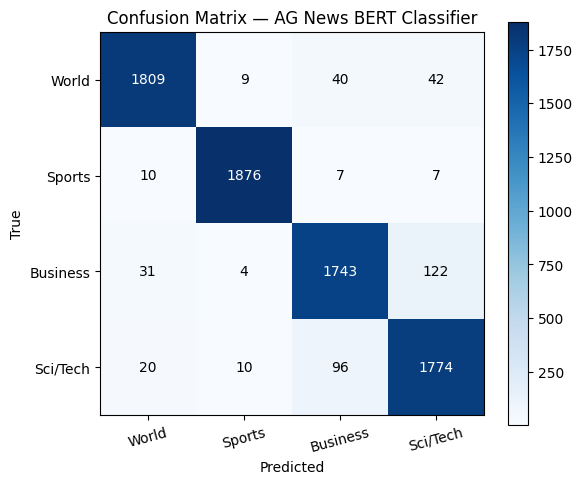

Heatmap saved as confusion_matrix.png


In [24]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

# Print as a readable table
print("── Confusion Matrix ───────────────────────────────────────────")
header = f"{'':12s}" + "".join(f"{n:11s}" for n in LABEL_NAMES)
print(header)
print("-" * len(header))
for i, row in enumerate(cm):
    row_str = "".join(f"{v:11d}" for v in row)
    print(f"  {LABEL_NAMES[i]:10s}{row_str}")
print("\n  Rows = true class   |   Columns = predicted class")

# Visual heatmap using matplotlib
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_LABELS));  ax.set_xticklabels(LABEL_NAMES, rotation=15)
ax.set_yticks(range(NUM_LABELS));  ax.set_yticklabels(LABEL_NAMES)
ax.set_xlabel("Predicted");        ax.set_ylabel("True")
ax.set_title("Confusion Matrix — AG News BERT Classifier")

# Annotate each cell with the count
for i in range(NUM_LABELS):
    for j in range(NUM_LABELS):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Heatmap saved as confusion_matrix.png")

---
## 🚀 Phase 5 — Gradio Web App

Type any news headline and the model returns the predicted category
plus a confidence bar chart for all four classes.

> The public Gradio link stays live for **72 hours** — share it with your internship supervisor to demo the project.

In [25]:
import gradio as gr

# ── Label display names with emoji ───────────────────────────────────────────
LABEL_EMOJI = {
    "World"    : "🌍 World",
    "Sports"   : "⚽ Sports",
    "Business" : "💼 Business",
    "Sci/Tech" : "🔬 Sci/Tech",
}

# ── Prediction function ───────────────────────────────────────────────────────
def predict(headline: str):
    """
    Takes a news headline string.
    Returns (top_prediction_label, confidence_dict_for_all_classes).
    Gradio's Label component renders the dict as a confidence bar chart.
    """
    if not headline.strip():
        return "Please enter a headline.", {}

    # Tokenize the single input headline
    inputs = eval_tokenizer(
        headline,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Forward pass — no gradient needed for inference
    with torch.no_grad():
        logits = eval_model(**inputs).logits        # shape: (1, 4)

    # Convert logits to probabilities with softmax
    probs    = torch.softmax(logits, dim=-1).cpu().numpy()[0]  # shape: (4,)
    pred_idx = int(np.argmax(probs))

    top_label  = LABEL_EMOJI[LABEL_NAMES[pred_idx]]
    confidence = {
        LABEL_EMOJI[LABEL_NAMES[i]]: float(probs[i])
        for i in range(NUM_LABELS)
    }
    return top_label, confidence


# ── Example headlines for quick testing ──────────────────────────────────────
EXAMPLES = [
    ["NASA discovers water ice deposits near the Moon's south pole"],
    ["Apple reports record quarterly earnings driven by iPhone sales"],
    ["Manchester United defeats Chelsea 3-1 in Premier League clash"],
    ["UN Security Council meets to address escalating Middle East tensions"],
    ["New AI model outperforms humans on complex reasoning benchmarks"],
    ["Federal Reserve raises interest rates by 25 basis points"],
]


# ── Build the Gradio UI ───────────────────────────────────────────────────────
with gr.Blocks(title="News Topic Classifier") as demo:

    gr.Markdown(
        """
        ## 📰 News Topic Classifier
        Fine-tuned **BERT** (`bert-base-uncased`) on the AG News dataset.
        Enter any news headline to classify it into one of four topics:
        **World · Sports · Business · Sci/Tech**
        """
    )

    with gr.Row():
        with gr.Column(scale=2):
            headline_box = gr.Textbox(
                label="News headline",
                placeholder="e.g. Tesla unveils its new electric truck model...",
                lines=2,
            )
            classify_btn = gr.Button("Classify", variant="primary")

        with gr.Column(scale=1):
            top_pred   = gr.Textbox(label="Top prediction")
            confidence = gr.Label(label="Confidence scores", num_top_classes=4)

    gr.Examples(examples=EXAMPLES, inputs=headline_box, label="Try an example")

    classify_btn.click(
        fn=predict,
        inputs=headline_box,
        outputs=[top_pred, confidence],
    )

    gr.Markdown(
        "_Model: bert-base-uncased · Dataset: AG News · Expected accuracy: ~94–95%_"
    )


# share=True generates a public link valid for 72 hours
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://83924d330662b300d0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
